In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# **1. Import Data**

In [2]:
df = pd.read_csv('heartDisease.csv')
df

,age,sex,chest pain,trestbps,cholestoral,fasting blood sugar,restecg,heartbeat,exang,oldpeak,slope,ca,thalium,diagnosis
0,63,Male,Asymptomatic,145,233,1,0,150,0,2.3,Upsloping,0,1,Abnormal
1,37,Male,Non-anginal pain,130,250,0,1,187,0,3.5,Upsloping,0,2,Abnormal
2,41,Female,Atypical angina,130,204,0,0,172,0,1.4,Downslopins,0,2,Abnormal
3,56,Male,Atypical angina,120,236,0,1,178,0,0.8,Downslopins,0,2,Abnormal
4,57,Female,Typical angina,120,354,0,1,163,1,0.6,Downslopins,0,2,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,Female,Typical angina,140,241,0,1,123,1,0.2,Flatsloping,0,3,Normal
299,45,Male,Asymptomatic,110,264,0,1,132,0,1.2,Flatsloping,0,3,Normal
300,68,Male,Typical angina,144,193,1,1,141,0,3.4,Flatsloping,2,3,Normal
301,57,Male,Typical angina,130,131,0,1,115,1,1.2,Flatsloping,1,3,Normal


In [3]:
df.shape

(303, 14)

In [4]:
df.diagnosis.value_counts()

diagnosis
Abnormal    165
Normal      138
Name: count, dtype: int64

# **2. Data Cleaning**

In [5]:
df.isnull().sum()

age                    0
sex                    0
chest pain             0
trestbps               0
cholestoral            0
fasting blood sugar    0
restecg                0
heartbeat              0
exang                  0
oldpeak                0
slope                  0
ca                     0
thalium                0
diagnosis              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
#drop duplicated data if any
df = df.drop_duplicates()

In [8]:
#check duplicated data
df.duplicated().sum()

np.int64(0)

# **3. Exploratory Data Analysis (EDA)**

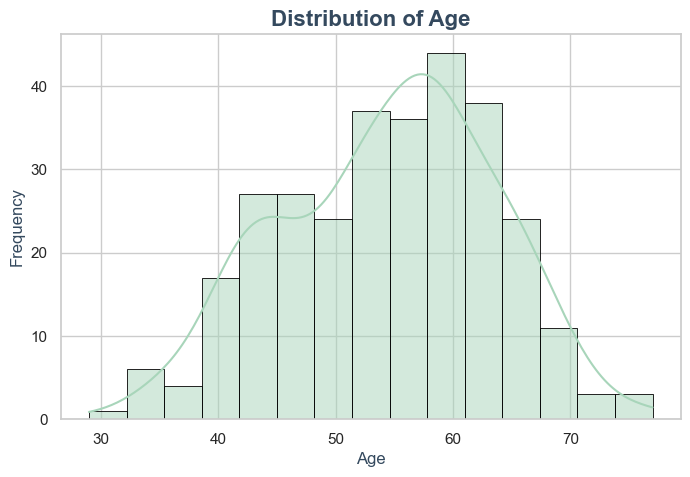

In [23]:

sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', bins=15, kde=True, color='#A8D5BA', edgecolor="black", linewidth=0.6) 
plt.title('Distribution of Age', fontsize=16, fontweight='bold', color='#34495E')
plt.xlabel('Age', fontsize=12, color='#34495E')
plt.ylabel('Frequency', fontsize=12, color='#34495E')
plt.show();


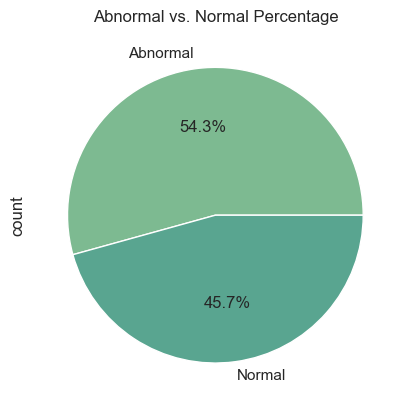

In [10]:
sns.set_palette("crest")
df['diagnosis'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Abnormal vs. Normal Percentage')
plt.show();

# **4. Data Preparation**

**4.1. Data Encoding**

In [11]:
df

,age,sex,chest pain,trestbps,cholestoral,fasting blood sugar,restecg,heartbeat,exang,oldpeak,slope,ca,thalium,diagnosis
0,63,Male,Asymptomatic,145,233,1,0,150,0,2.3,Upsloping,0,1,Abnormal
1,37,Male,Non-anginal pain,130,250,0,1,187,0,3.5,Upsloping,0,2,Abnormal
2,41,Female,Atypical angina,130,204,0,0,172,0,1.4,Downslopins,0,2,Abnormal
3,56,Male,Atypical angina,120,236,0,1,178,0,0.8,Downslopins,0,2,Abnormal
4,57,Female,Typical angina,120,354,0,1,163,1,0.6,Downslopins,0,2,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,Female,Typical angina,140,241,0,1,123,1,0.2,Flatsloping,0,3,Normal
299,45,Male,Asymptomatic,110,264,0,1,132,0,1.2,Flatsloping,0,3,Normal
300,68,Male,Typical angina,144,193,1,1,141,0,3.4,Flatsloping,2,3,Normal
301,57,Male,Typical angina,130,131,0,1,115,1,1.2,Flatsloping,1,3,Normal


In [12]:
from sklearn.preprocessing import LabelEncoder

sx_encoder = LabelEncoder() #sex encoding
cp_encoder = LabelEncoder() #chestpain encoding
s_encoder = LabelEncoder() #slope encoding

df['sex'] = sx_encoder.fit_transform(df['sex'])
df['chest pain'] = cp_encoder.fit_transform(df['chest pain'])
df['slope'] = s_encoder.fit_transform(df['slope'])
df['diagnosis'] = df['diagnosis'].map({'Abnormal': 1, 'Normal': 0})

df.head()

/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_20183/2978104595.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'] = sx_encoder.fit_transform(df['sex'])
/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_20183/2978104595.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['chest pain'] = cp_encoder.fit_transform(df['chest pain'])
/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_20183/2978104595.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy o

,age,sex,chest pain,trestbps,cholestoral,fasting blood sugar,restecg,heartbeat,exang,oldpeak,slope,ca,thalium,diagnosis
0,63,1,0,145,233,1,0,150,0,2.3,2,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,2,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,0,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,0,0,2,1
4,57,0,3,120,354,0,1,163,1,0.6,0,0,2,1


In [13]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print("X : ", X.shape)
print("y : ", y.shape)

X :  (302, 13)
y :  (302,)


In [14]:
scaler = StandardScaler()
scaler.fit(X)
X = scaler.fit_transform(X)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=78)

# **5. Modeling and Evaluation (SVM, KNN, Decision Tree)**

In [25]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(kernel='linear')
}

In [26]:
result = []
for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    result.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': report["weighted avg"]["precision"],
        'Recall': report["weighted avg"]["recall"],
        'F1-Score': report["weighted avg"]["f1-score"]
    })
evaluation_df = pd.DataFrame(result)
evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.769231,0.771909,0.769231,0.769735
1,K-Nearest Neighbors,0.824176,0.825571,0.824176,0.824475
2,Support Vector Machine,0.879121,0.881560,0.879121,0.879385


**F1 Score:**
* 1.0 = Perfect precision & recall
* 0.8–0.9 = Excellent
* 0.6–0.8 = Good / decent
* < 0.5 = Weak performance


**Recall** = of all the actual positives, how many did the model correctly identify?

**Recall** = True Positives / (True Positives+False Negatives)

* High recall → your model rarely misses positive cases (few false negatives).
* Low recall → your model often misses positives (many false negatives).

In [18]:
df.head()

,age,sex,chest pain,trestbps,cholestoral,fasting blood sugar,restecg,heartbeat,exang,oldpeak,slope,ca,thalium,diagnosis
0,63,1,0,145,233,1,0,150,0,2.3,2,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,2,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,0,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,0,0,2,1
4,57,0,3,120,354,0,1,163,1,0.6,0,0,2,1


# **6. Testing**

In [31]:
# Collect user inputs
age = int(input("Enter age: "))
sex = input("Enter sex (Male/Female): ").capitalize()
chest_pain = input("Enter chest pain type (Asymptomatic / Non-anginal pain / Atypical angina / Typical angina): ").capitalize()
trestbps = int(input("Enter resting blood pressure (trestbps): "))
cholestoral = int(input("Enter cholestoral level: "))
fbs = int(input("Enter fasting blood sugar (1 = True, 0 = False): "))
restecg = int(input("Enter resting ECG (0, 1, or 2): "))
heartbeat = int(input("Enter maximum heart rate achieved: "))
exang = int(input("Exercise induced angina (1 = Yes, 0 = No): "))
oldpeak = float(input("Enter ST depression induced by exercise (oldpeak): "))
slope = input("Enter slope type (Upsloping / Flatsloping / Downsloping): ").capitalize()
ca = int(input("Enter number of major vessels (0–4): "))
thalium = int(input("Enter thalium value (0–3): "))

# Create DataFrame
new_data = pd.DataFrame({
    'age': [age],
    'sex': [sex],
    'chest pain': [chest_pain],
    'trestbps': [trestbps],
    'cholestoral': [cholestoral],
    'fasting blood sugar': [fbs],
    'restecg': [restecg],
    'heartbeat': [heartbeat],
    'exang': [exang],
    'oldpeak': [oldpeak],
    'slope': [slope],
    'ca': [ca],
    'thalium': [thalium],
})

print("\n✅ User Input DataFrame:")
display(new_data)

Enter age:  67
Enter sex (Male/Female):  male
Enter chest pain type (Asymptomatic / Non-anginal pain / Atypical angina / Typical angina):  Typical angina
Enter resting blood pressure (trestbps):  150
Enter cholestoral level:  233
Enter fasting blood sugar (1 = True, 0 = False):  0
Enter resting ECG (0, 1, or 2):  2
Enter maximum heart rate achieved:  165
Exercise induced angina (1 = Yes, 0 = No):  0
Enter ST depression induced by exercise (oldpeak):  3.5
Enter slope type (Upsloping / Flatsloping / Downsloping):  Flatsloping
Enter number of major vessels (0–4):  1
Enter thalium value (0–3):  1



✅ User Input DataFrame:


,age,sex,chest pain,trestbps,cholestoral,fasting blood sugar,restecg,heartbeat,exang,oldpeak,slope,ca,thalium
0,67,Male,Typical angina,150,233,0,2,165,0,3.5,Flatsloping,1,1


In [32]:
new_data['sex'] = sx_encoder.transform(new_data['sex'])
new_data['chest pain'] = cp_encoder.transform(new_data['chest pain'])
new_data['slope'] = s_encoder.transform(new_data['slope'])
new_data

,age,sex,chest pain,trestbps,cholestoral,fasting blood sugar,restecg,heartbeat,exang,oldpeak,slope,ca,thalium
0,67,1,3,150,233,0,2,165,0,3.5,1,1,1


In [33]:
new_data_scaled = scaler.transform(new_data)

for model_name, model in models.items():
    prediction = model.predict(new_data_scaled)
    print(f"Prediction for {model_name}: {'Abnormal' if prediction[0] == 1 else 'Normal'}")

Prediction for Decision Tree: Normal
Prediction for K-Nearest Neighbors: Normal
Prediction for Support Vector Machine: Normal
